In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
img_bgr = cv2.imread(filename)

# Convert to RGB for plotting
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

H, S, V = cv2.split(hsv)

Saving WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg to WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg


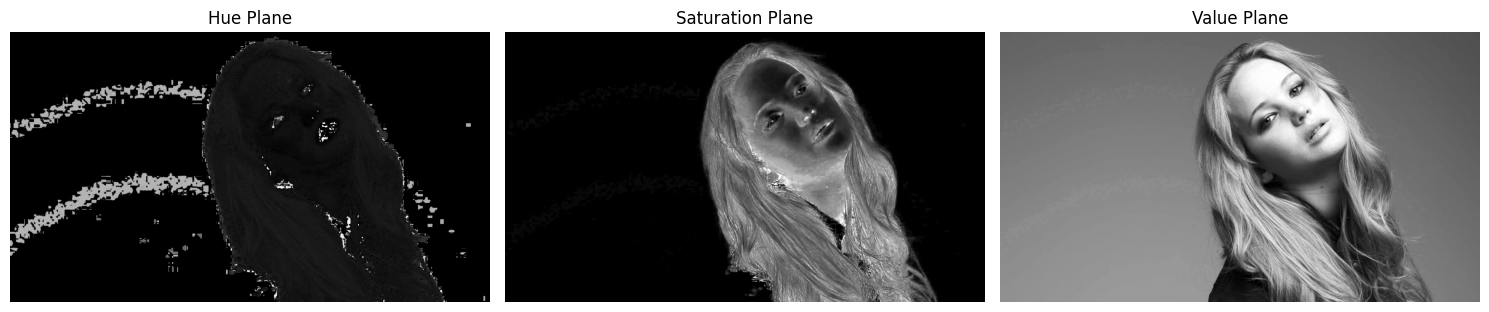

In [2]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray')
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray')
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray')
plt.title("Value Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
threshold, mask = cv2.threshold(
    S,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Threshold selected:", threshold)

Threshold selected: 60.0


In [4]:
threshold, mask = cv2.threshold(
    S,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Threshold selected:", threshold)

Threshold selected: 60.0


In [5]:
kernel = np.ones((5, 5), np.uint8)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

In [6]:
V_foreground = cv2.bitwise_and(
    V,
    V,
    mask=mask
)

In [7]:
V_foreground = cv2.bitwise_and(
    V,
    V,
    mask=mask
)

In [ ]:
hist = np.zeros(256, dtype=int)

foreground_pixels = V[mask > 0]

for pixel in foreground_pixels:
    hist[pixel] += 1


In [10]:
# Extract only foreground pixels from the V plane
foreground_pixels = V[mask > 0]

# Compute histogram
hist = np.zeros(256, dtype=int)

for pixel in foreground_pixels:
    hist[pixel] += 1

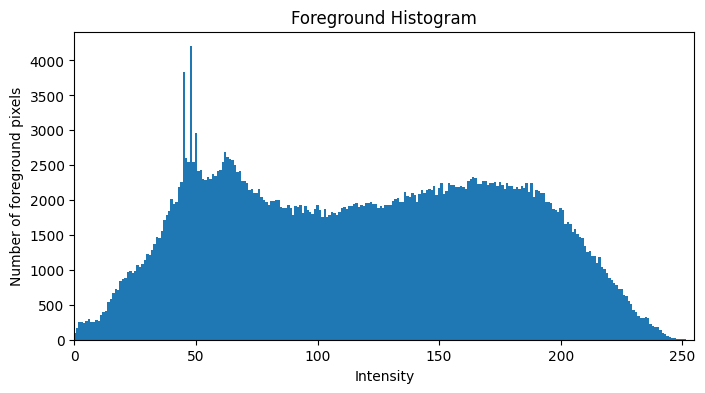

In [11]:
plt.figure(figsize=(8, 4))

plt.bar(np.arange(256), hist, width=1)

plt.xlabel("Intensity")
plt.ylabel("Number of foreground pixels")
plt.title("Foreground Histogram")

plt.xlim(0, 255)
plt.show()

In [12]:
cdf = np.cumsum(hist)

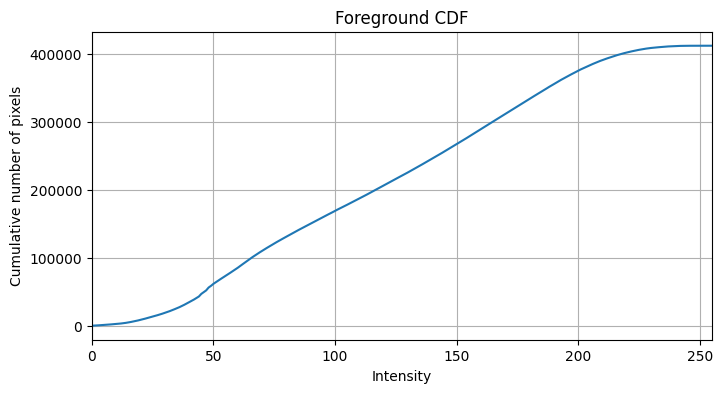

In [13]:
plt.figure(figsize=(8, 4))

plt.plot(cdf)

plt.xlabel("Intensity")
plt.ylabel("Cumulative number of pixels")
plt.title("Foreground CDF")

plt.xlim(0, 255)
plt.grid()

plt.show()

In [14]:
# Number of foreground pixels
N = np.sum(mask > 0)

# First non-zero CDF value
cdf_min = cdf[cdf > 0][0]

# Histogram equalization transformation
T = np.round(
    255 * (cdf - cdf_min) / (N - cdf_min)
)

T = np.clip(T, 0, 255).astype(np.uint8)

In [15]:
background_mask = cv2.bitwise_not(mask)

In [16]:
V_equalized_fg = np.zeros_like(V)

V_equalized_fg[mask > 0] = T[V[mask > 0]]

In [17]:
V_background = cv2.bitwise_and(
    V,
    V,
    mask=background_mask
)

In [19]:
# Combine original background and equalized foreground
V_result = cv2.add(
    V_background,
    V_equalized_fg
)

In [20]:
hsv_result = cv2.merge([
    H,
    S,
    V_result
])

result_bgr = cv2.cvtColor(
    hsv_result,
    cv2.COLOR_HSV2BGR
)

result_rgb = cv2.cvtColor(
    result_bgr,
    cv2.COLOR_BGR2RGB
)

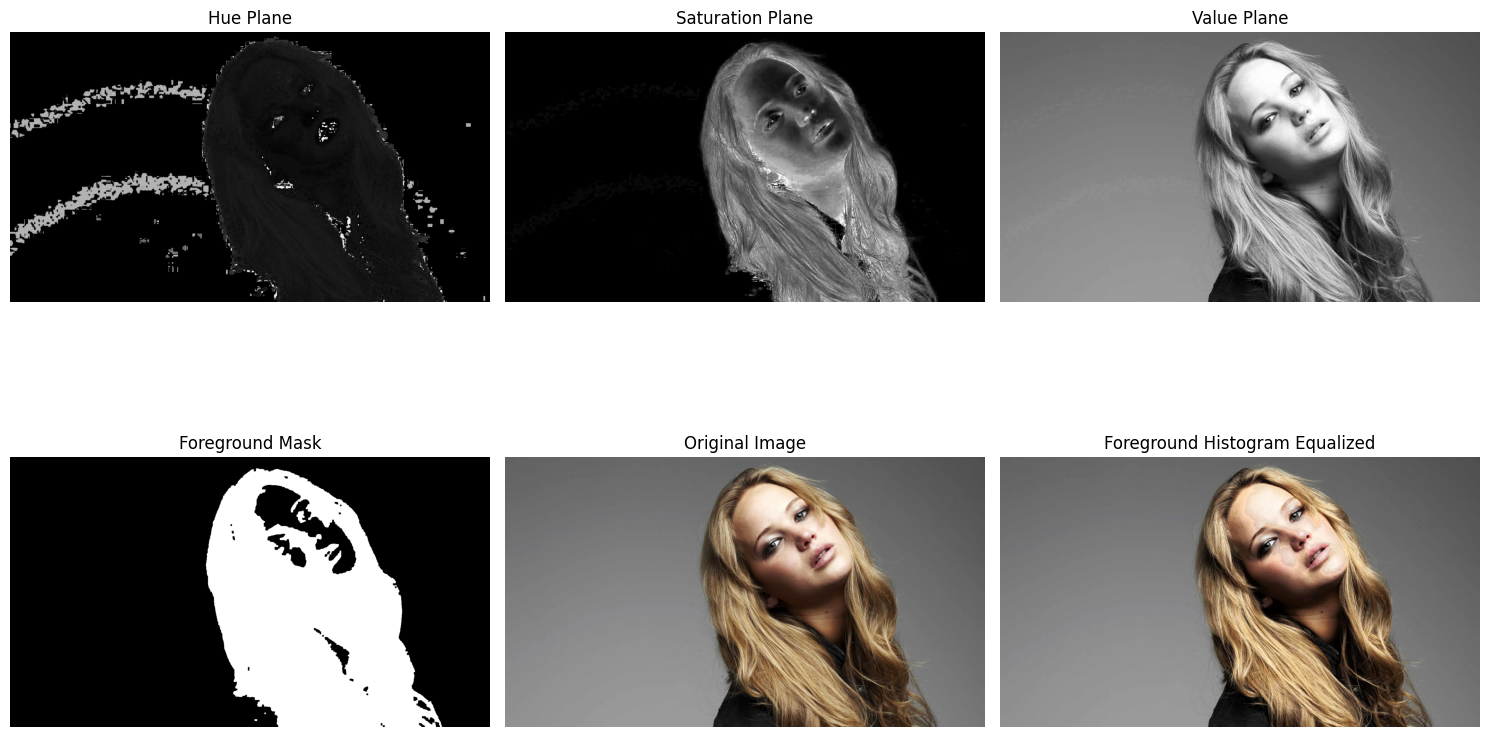

In [21]:
plt.figure(figsize=(15, 10))

# Hue
plt.subplot(2, 3, 1)
plt.imshow(H, cmap='gray')
plt.title("Hue Plane")
plt.axis("off")

# Saturation
plt.subplot(2, 3, 2)
plt.imshow(S, cmap='gray')
plt.title("Saturation Plane")
plt.axis("off")

# Value
plt.subplot(2, 3, 3)
plt.imshow(V, cmap='gray')
plt.title("Value Plane")
plt.axis("off")

# Mask
plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title("Foreground Mask")
plt.axis("off")

# Original
plt.subplot(2, 3, 5)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

# Result
plt.subplot(2, 3, 6)
plt.imshow(result_rgb)
plt.title("Foreground Histogram Equalized")
plt.axis("off")

plt.tight_layout()
plt.show()

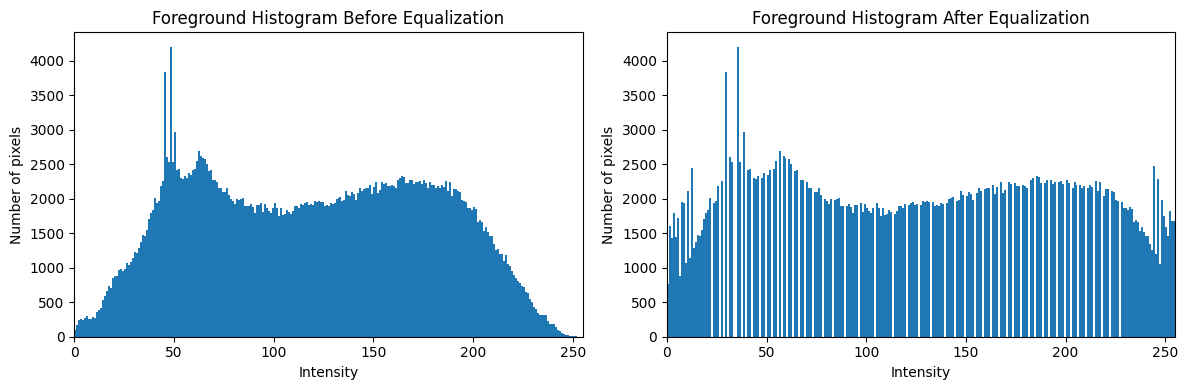

In [22]:
original_fg = V[mask > 0]
equalized_fg = V_result[mask > 0]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(
    original_fg,
    bins=256,
    range=(0, 256)
)
plt.title("Foreground Histogram Before Equalization")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.xlim(0, 255)


plt.subplot(1, 2, 2)
plt.hist(
    equalized_fg,
    bins=256,
    range=(0, 256)
)
plt.title("Foreground Histogram After Equalization")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()